In [1]:
# CELL 1 — Imports + setup

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psycopg2
import itertools

from sklearn.linear_model import LinearRegression, ElasticNetCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit


warnings.filterwarnings("ignore")


try:
    import xgboost as xgb
    HAS_XGB = True
except Exception:
    from sklearn.ensemble import RandomForestRegressor
    HAS_XGB = False


# Directory for all graphs/metrics tables in the project folder
OUTDIR = "figures"
os.makedirs(OUTDIR, exist_ok=True)

plt.rcParams["figure.dpi"] = 140
plt.rcParams["font.size"] = 11
np.random.seed(42)

In [2]:

# CELL 2 - Feature Engineering/Setup
# In this cell our goal is to create the engineered features pulling from our PostgreSQL database, and to set up the data we need within this notebook


# Database Config (local to machine)
DB_CONFIG = {
    "host": "localhost",
    "port": 5432,
    "dbname": "capstone_170b",
    "user": "postgres",
    "password": "password"
}

# Settings
START = "2005-01-01"
END   = "2024-12-31"

# Helpers
def monthly_log_return(level_series):
    m = level_series.resample("ME").last()
    return np.log(m / m.shift(1))

# 1) Load tables from Postgres
conn = psycopg2.connect(**DB_CONFIG)

market_raw = pd.read_sql(
    """
    SELECT trade_date, ticker, adj_close
    FROM market_raw
    WHERE trade_date BETWEEN %(start)s AND %(end)s
      AND ticker IN ('SPY', '^VIX', 'FXI', 'CL=F')
    ORDER BY trade_date, ticker
    """,
    conn,
    params={"start": START, "end": END}
)

macro = pd.read_sql(
    """
    SELECT observation_date, series_id, value
    FROM macro_observations
    WHERE observation_date BETWEEN %(start)s AND %(end)s
      AND series_id IN ('CPIAUCSL', 'UNRATE', 'DGS10', 'NAPMPI', 'NAPM', 'ISM/MAN_PMI')
    ORDER BY observation_date, series_id
    """,
    conn,
    params={"start": START, "end": END}
)

fomc = pd.read_sql(
    """
    SELECT meeting_date, hawkish_score
    FROM fomc_minutes
    WHERE meeting_date BETWEEN %(start)s AND %(end)s
    ORDER BY meeting_date
    """,
    conn,
    params={"start": START, "end": END}
)

conn.close()

# 2) Market price panel
market_raw["trade_date"] = pd.to_datetime(market_raw["trade_date"])
market_raw["adj_close"] = pd.to_numeric(market_raw["adj_close"], errors="coerce")

px_adj = (
    market_raw
    .pivot(index="trade_date", columns="ticker", values="adj_close")
    .sort_index()
)

px_adj.index.name = "trade_date"

# Individual series
spy_adj = px_adj["SPY"].dropna() if "SPY" in px_adj.columns else pd.Series(dtype=float)
vix_lvl = px_adj["^VIX"].dropna() if "^VIX" in px_adj.columns else pd.Series(dtype=float)
fxi_adj = px_adj["FXI"].dropna() if "FXI" in px_adj.columns else pd.Series(dtype=float)
oil_lvl = px_adj["CL=F"].dropna() if "CL=F" in px_adj.columns else pd.Series(dtype=float)

# Target
spy_mret = monthly_log_return(spy_adj).rename("spy_log_ret_m")

# Market features
vix_m = vix_lvl.resample("ME").last().rename("vix_m")
log_vix_m = np.log(vix_m).rename("log_vix_m")

fxi_mret = monthly_log_return(fxi_adj).rename("fxi_log_ret_m")
oil_mret = monthly_log_return(oil_lvl).rename("oil_log_ret_m")

# Momentum control
spy_m = spy_adj.resample("ME").last()
mom_3m = np.log(spy_m / spy_m.shift(3)).rename("mom_3m_log")
mom_3m_lag1 = mom_3m.shift(1).rename("mom_3m_log_lag1")


# 3) Macro features
macro["observation_date"] = pd.to_datetime(macro["observation_date"])
macro["value"] = pd.to_numeric(macro["value"], errors="coerce")

macro_wide = (
    macro
    .pivot(index="observation_date", columns="series_id", values="value")
    .sort_index()
)

macro_m = macro_wide.resample("ME").last()

# Match old naming
cpi = macro_m["CPIAUCSL"].rename("cpi_idx") if "CPIAUCSL" in macro_m.columns else None
unr = macro_m["UNRATE"].rename("unrate") if "UNRATE" in macro_m.columns else None
dgs = macro_m["DGS10"].rename("dgs10") if "DGS10" in macro_m.columns else None

# PMI fallback logic from DB instead of FRED
pmi = None
pmi_id = None
for candidate in ["NAPMPI", "NAPM", "ISM/MAN_PMI"]:
    if candidate in macro_m.columns and macro_m[candidate].notna().sum() > 0:
        pmi = macro_m[candidate].rename("pmi")
        pmi_id = candidate
        break

# Transformations
cpi_yoy = (cpi.pct_change(12) * 100.0).rename("cpi_yoy_pct") if cpi is not None else None
unrate  = unr.rename("unrate") if unr is not None else None
dgs10   = dgs.rename("dgs10") if dgs is not None else None
pmi     = pmi.rename("pmi") if pmi is not None else None

# 4) FOMC sentiment
full_index = spy_mret.index
fomc_sent = pd.Series(index=full_index, data=np.nan, name="fomc_hawk_proxy_m")

if len(fomc) > 0:
    fomc["meeting_date"] = pd.to_datetime(fomc["meeting_date"])
    fomc["hawkish_score"] = pd.to_numeric(fomc["hawkish_score"], errors="coerce")
    fomc = fomc.dropna(subset=["meeting_date"])

    fomc["month_end"] = fomc["meeting_date"].dt.to_period("M").dt.to_timestamp("M")

    sent = (
        fomc.groupby("month_end")["hawkish_score"]
        .mean()
        .rename("fomc_hawk_proxy_m")
    )

    fomc_sent = sent.reindex(full_index).ffill()

# 5) Build final engineered dataset
cols = [
    spy_mret,
    mom_3m_lag1,
    vix_m.shift(1).rename("vix_m_lag1"),
    log_vix_m.shift(1).rename("log_vix_m_lag1"),
    fxi_mret.shift(1).rename("fxi_log_ret_m_lag1"),
    oil_mret.shift(1).rename("oil_log_ret_m_lag1"),
    fomc_sent.shift(1).rename("fomc_hawk_proxy_m_lag1"),
]

if cpi_yoy is not None:
    cols.append(cpi_yoy.shift(1).rename("cpi_yoy_pct_lag1"))
if unrate is not None:
    cols.append(unrate.shift(1).rename("unrate_lag1"))
if dgs10 is not None:
    cols.append(dgs10.shift(1).rename("dgs10_lag1"))
if pmi is not None:
    cols.append(pmi.shift(1).rename("pmi_lag1"))

engineered = pd.concat(cols, axis=1).dropna(subset=["spy_log_ret_m"]).reset_index()
engineered = engineered.rename(columns={"index": "month_end"})
engineered["month_end"] = pd.to_datetime(engineered["month_end"])

print("Engineered dataset built from Postgres.")
print("Rows:", len(engineered))
print("Columns:", list(engineered.columns))
print("PMI series used:", pmi_id)
print()
print("Loaded tables:")
print("market_raw rows used:", len(market_raw))
print("macro rows used:", len(macro))
print("fomc rows used:", len(fomc))

Engineered dataset built from Postgres.
Rows: 239
Columns: ['month_end', 'spy_log_ret_m', 'mom_3m_log_lag1', 'vix_m_lag1', 'log_vix_m_lag1', 'fxi_log_ret_m_lag1', 'oil_log_ret_m_lag1', 'fomc_hawk_proxy_m_lag1', 'cpi_yoy_pct_lag1', 'unrate_lag1', 'dgs10_lag1']
PMI series used: None

Loaded tables:
market_raw rows used: 20125
macro rows used: 5484
fomc rows used: 138


In [3]:
# CELL 3 — Prepare modeling data

df = engineered.copy()

# We make sure month_end is datetime and sorted
df["month_end"] = pd.to_datetime(df["month_end"])
df = df.sort_values("month_end").reset_index(drop=True)

target_col = "spy_log_ret_m"


candidate_features = [
    "mom_3m_log_lag1",
    "vix_m_lag1",
    "log_vix_m_lag1",
    "fxi_log_ret_m_lag1",
    "oil_log_ret_m_lag1",
    "fomc_hawk_proxy_m_lag1",
    "cpi_yoy_pct_lag1",
    "unrate_lag1",
    "dgs10_lag1",
    "pmi_lag1",
]

feature_cols = [c for c in candidate_features if c in df.columns]

df = df.dropna(subset=[target_col]).copy()

# For modeling, we drop rows where all features are missing
df = df.dropna(subset=feature_cols, how="all").copy()

print("Rows:", len(df))
print("Target:", target_col)
print("Features used:", feature_cols)

Rows: 239
Target: spy_log_ret_m
Features used: ['mom_3m_log_lag1', 'vix_m_lag1', 'log_vix_m_lag1', 'fxi_log_ret_m_lag1', 'oil_log_ret_m_lag1', 'fomc_hawk_proxy_m_lag1', 'cpi_yoy_pct_lag1', 'unrate_lag1', 'dgs10_lag1']


In [4]:
# CELL 4 — Rolling 3-year window models

# 3 years of monthly data
WINDOW = 36   
MIN_NONMISSING_FEATURES = 3

results = []
# Elastic Net coefficients over time
coef_rows = []        

# Helper for later metrics
def sign_accuracy(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(np.sign(y_true) == np.sign(y_pred))

# Iterate so each month after the first 36 gets predicted from the previous 36 months
for t in range(WINDOW, len(df)):
    train = df.iloc[t-WINDOW:t].copy()
    test = df.iloc[[t]].copy()

    # Use only existing and are not "too missing" inside this training window (as defined by MIN_NONMISSING_FEATURES)
    usable = []
    for c in feature_cols:
        if train[c].notna().sum() >= MIN_NONMISSING_FEATURES:
            usable.append(c)

    if len(usable) == 0:
        continue

    # Drop rows with missing features for model-fitting
    train_full = train.dropna(subset=usable).copy()
    test_full = test.dropna(subset=usable).copy()

    # If the current month has missing features, we skip the prediction
    if len(test_full) == 0:
        continue

    # If too few training rows remain after dropping NA, we skip
    if len(train_full) < 18:
        continue

    X_train = train_full[usable]
    y_train = train_full[target_col].values
    X_test = test_full[usable]
    y_test = test_full[target_col].values[0]

    pred_dict = {
        "month_end": test_full["month_end"].iloc[0],
        "actual": y_test,
    }

    # 1) Baseline: rolling historical mean
    pred_mean = float(np.mean(y_train))
    pred_dict["pred_mean"] = pred_mean

    # 2) Baseline: momentum-only linear regression
    if "mom_3m_log_lag1" in usable:
        mom_train = train_full[["mom_3m_log_lag1"]]
        mom_test = test_full[["mom_3m_log_lag1"]]

        lr_mom = LinearRegression()
        lr_mom.fit(mom_train, y_train)
        pred_dict["pred_mom_lr"] = float(lr_mom.predict(mom_test)[0])
    else:
        pred_dict["pred_mom_lr"] = np.nan

    # 3) Rolling Elastic Net
    # We use time-series CV inside each rolling training window
    n_train = len(train_full)
    n_splits = min(3, max(2, n_train // 10))

    enet_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("enet", ElasticNetCV(
            l1_ratio=[0.5, 0.7, 0.9],              
            alphas=np.logspace(-2, 0.5, 25),      
            cv=TimeSeriesSplit(n_splits=n_splits),
            max_iter=50000,
            tol=1e-4,
            random_state=42
        ))
    ])

    enet_pipe.fit(X_train, y_train)
    pred_dict["pred_enet"] = float(enet_pipe.predict(X_test)[0])

    # Store coefficients for heatmap
    enet_model = enet_pipe.named_steps["enet"]
    coef_map = {"month_end": test_full["month_end"].iloc[0]}
    for f, coef in zip(usable, enet_model.coef_):
        coef_map[f] = coef
    coef_rows.append(coef_map)

    # 4) Rolling nonlinear model (XGB preferred, else RF)
    if HAS_XGB:
        tree_model = xgb.XGBRegressor(
            n_estimators=400,
            max_depth=4,
            learning_rate=0.03,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            min_child_weight=3,
            gamma=0.1,
            random_state=42,
            n_jobs=4
        )
    else:
        tree_model = RandomForestRegressor(
            n_estimators=300,
            max_depth=6,
            random_state=42,
            n_jobs=4
        )

    tree_model.fit(X_train, y_train)
    pred_dict["pred_tree"] = float(tree_model.predict(X_test)[0])



    results.append(pred_dict)

rolling_preds = pd.DataFrame(results).sort_values("month_end").reset_index(drop=True)
coef_df = pd.DataFrame(coef_rows).sort_values("month_end").reset_index(drop=True)

print("Prediction rows:", len(rolling_preds))
print("Coefficient rows:", len(coef_df))
print("Tree model used:", "XGBoost" if HAS_XGB else "RandomForest")

Prediction rows: 188
Coefficient rows: 188
Tree model used: XGBoost


In [5]:
# CELL 5 — Evaluation metrics
# Here we calculate and display ceratin metrics for both our baselines and the Elastic Net
# Note that the tree model used for comparison here is a simplified version, meant as a baseline comparison for a non-linear vs. linear approach

def metric_block(actual, pred):
    mask = pd.notna(actual) & pd.notna(pred)
    y = np.asarray(actual[mask])
    p = np.asarray(pred[mask])

    return {
        "RMSE": np.sqrt(mean_squared_error(y, p)),
        "MAE": mean_absolute_error(y, p),
        "Directional_Accuracy": sign_accuracy(y, p),
        "N_Predictions": len(y)
    }

metric_rows = []

for col, label in [
    ("pred_mean", "Historical Mean"),
    ("pred_mom_lr", "Momentum-only LR"),
    ("pred_enet", "Rolling Elastic Net"),
    ("pred_tree", "Rolling Tree Model"),
]:
    m = metric_block(rolling_preds["actual"], rolling_preds[col])
    m["Model"] = label
    metric_rows.append(m)

metrics_df = pd.DataFrame(metric_rows)[
    ["Model", "RMSE", "MAE", "Directional_Accuracy", "N_Predictions"]
].sort_values("RMSE").reset_index(drop=True)

print(metrics_df)

                 Model      RMSE       MAE  Directional_Accuracy  \
0      Historical Mean  0.043716  0.033554              0.643617   
1   Rolling Tree Model  0.043757  0.033573              0.638298   
2     Momentum-only LR  0.044275  0.033820              0.617021   
3  Rolling Elastic Net  0.046735  0.034353              0.670213   

   N_Predictions  
0            188  
1            188  
2            188  
3            188  


In [6]:
# Poster figure defaults
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import os

POSTER_DPI = 600
POSTER_SIZE = (6.4, 3.15)   # good for poster middle column
SMALL_POSTER_SIZE = (5.8, 3.0)

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": POSTER_DPI,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def save_poster_fig(path):
    plt.tight_layout(pad=0.35)
    plt.savefig(path, dpi=POSTER_DPI, bbox_inches="tight", pad_inches=0.03)
    plt.show()
    print("Saved:", path)

Using features: ['fxi_log_ret_m_lag1', 'cpi_yoy_pct_lag1', 'unrate_lag1', 'oil_log_ret_m_lag1']


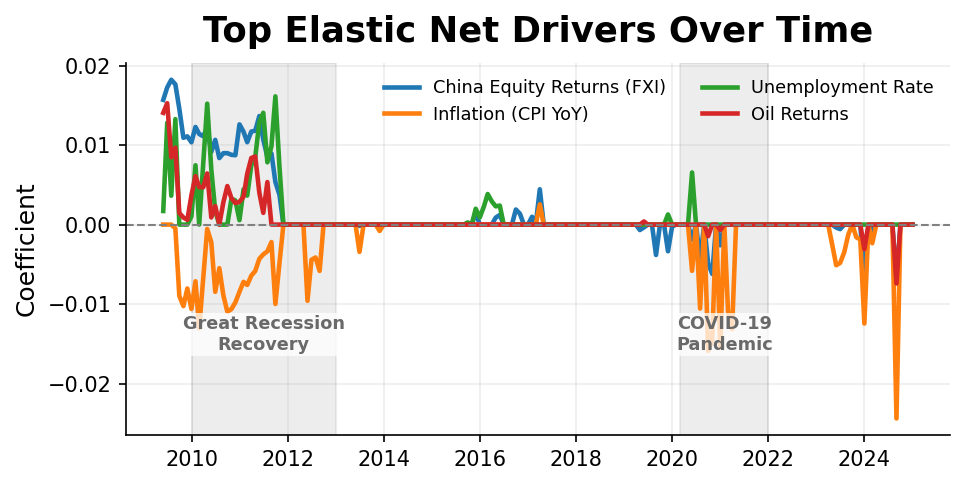

Saved: figures/poster_top_enet_drivers_regime_clean.png


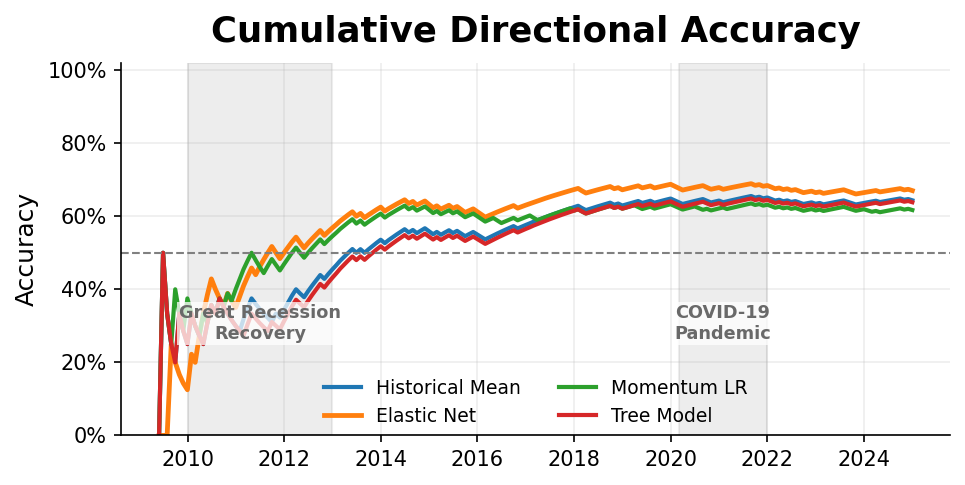

Saved: figures/poster_directional_accuracy_regime_clean.png


In [ ]:
# =====================================================
# POSTER GRAPHS — TOP DRIVERS + DIRECTIONAL ACCURACY
# GREAT RECESSION + COVID LABELS
# =====================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

os.makedirs(OUTDIR, exist_ok=True)

# -----------------------------------------------------
# Regime labels
# -----------------------------------------------------
REGIMES = [
    ("Great Recession\nRecovery", "2010-01-01", "2012-12-31"),
    ("COVID-19\nPandemic", "2020-03-01", "2022-01-01"),
]

def add_regime_bands(ax, label_frac=0.25):
    y0, y1 = ax.get_ylim()
    label_y = y0 + label_frac * (y1 - y0)

    for label, start, end in REGIMES:
        start = pd.to_datetime(start)
        end = pd.to_datetime(end)

        ax.axvspan(start, end, color="gray", alpha=0.14, zorder=0)

        mid = start + (end - start) / 2
        ax.text(
            mid,
            label_y,
            label,
            ha="center",
            va="center",
            fontsize=8.5,
            fontweight="bold",
            color="dimgray",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.0),
            zorder=5
        )

# -----------------------------------------------------
# Feature name helpers
# -----------------------------------------------------
feature_map = {
    "fxi_log_ret_m_lag1": "China Equity Returns (FXI)",
    "cpi_yoy_pct_lag1": "Inflation (CPI YoY)",
    "unrate_lag1": "Unemployment Rate",
    "oil_log_ret_m_lag1": "Oil Returns",
}

wanted_features = [
    "fxi_log_ret_m_lag1",
    "cpi_yoy_pct_lag1",
    "unrate_lag1",
    "oil_log_ret_m_lag1",
]

available_features = [c for c in wanted_features if c in coef_df.columns]

print("Using features:", available_features)

# =====================================================
# GRAPH 1 — TOP ELASTIC NET DRIVERS OVER TIME
# =====================================================

coef_plot = coef_df.copy()
coef_plot["month_end"] = pd.to_datetime(coef_plot["month_end"])
coef_plot = coef_plot.sort_values("month_end")

plt.figure(figsize=(6.4, 3.2))
ax = plt.gca()

for col in available_features:
    ax.plot(
        coef_plot["month_end"],
        coef_plot[col],
        linewidth=2.2,
        label=feature_map.get(col, col)
    )

ax.axhline(0, color="gray", linewidth=1, linestyle="--")

ax.set_title(
    "Top Elastic Net Drivers Over Time",
    fontsize=17,
    fontweight="bold",
    pad=10
)

ax.set_xlabel("")
ax.set_ylabel("Coefficient", fontsize=12)
ax.grid(alpha=0.22)

ax.legend(
    frameon=False,
    fontsize=8.5,
    ncol=2,
    loc="upper right"
)

add_regime_bands(ax, label_frac=0.2)

plt.tight_layout(pad=0.5)

outpath1 = os.path.join(OUTDIR, "poster_top_enet_drivers_regime_clean.png")
plt.savefig(outpath1, dpi=600, bbox_inches="tight", pad_inches=0.03)
plt.show()

print("Saved:", outpath1)

# =====================================================
# GRAPH 2 — CUMULATIVE DIRECTIONAL ACCURACY
# =====================================================

plot_df = rolling_preds.copy()
plot_df["month_end"] = pd.to_datetime(plot_df["month_end"])

plot_df["da_mean"] = (
    np.sign(plot_df["actual"]) == np.sign(plot_df["pred_mean"])
).expanding().mean()

plot_df["da_enet"] = (
    np.sign(plot_df["actual"]) == np.sign(plot_df["pred_enet"])
).expanding().mean()

if "pred_mom_lr" in plot_df.columns:
    plot_df["da_mom"] = (
        np.sign(plot_df["actual"]) == np.sign(plot_df["pred_mom_lr"])
    ).expanding().mean()

if "pred_tree" in plot_df.columns:
    plot_df["da_tree"] = (
        np.sign(plot_df["actual"]) == np.sign(plot_df["pred_tree"])
    ).expanding().mean()

plt.figure(figsize=(6.4, 3.2))
ax = plt.gca()

ax.plot(plot_df["month_end"], plot_df["da_mean"], linewidth=2, label="Historical Mean")
ax.plot(plot_df["month_end"], plot_df["da_enet"], linewidth=2.3, label="Elastic Net")

if "da_mom" in plot_df.columns:
    ax.plot(plot_df["month_end"], plot_df["da_mom"], linewidth=2, label="Momentum LR")

if "da_tree" in plot_df.columns:
    ax.plot(plot_df["month_end"], plot_df["da_tree"], linewidth=2, label="Tree Model")

ax.axhline(0.50, linestyle="--", linewidth=1, color="gray")

ax.set_title(
    "Cumulative Directional Accuracy",
    fontsize=17,
    fontweight="bold",
    pad=10
)

ax.set_xlabel("")
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_ylim(0, 1.02)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.grid(alpha=0.22)

ax.legend(
    frameon=False,
    ncol=2,
    fontsize=9,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02)
)

add_regime_bands(ax, label_frac=0.60)

plt.tight_layout(pad=0.5)

outpath2 = os.path.join(OUTDIR, "poster_directional_accuracy_regime_clean.png")
plt.savefig(outpath2, dpi=600, bbox_inches="tight", pad_inches=0.03)
plt.show()

print("Saved:", outpath2)

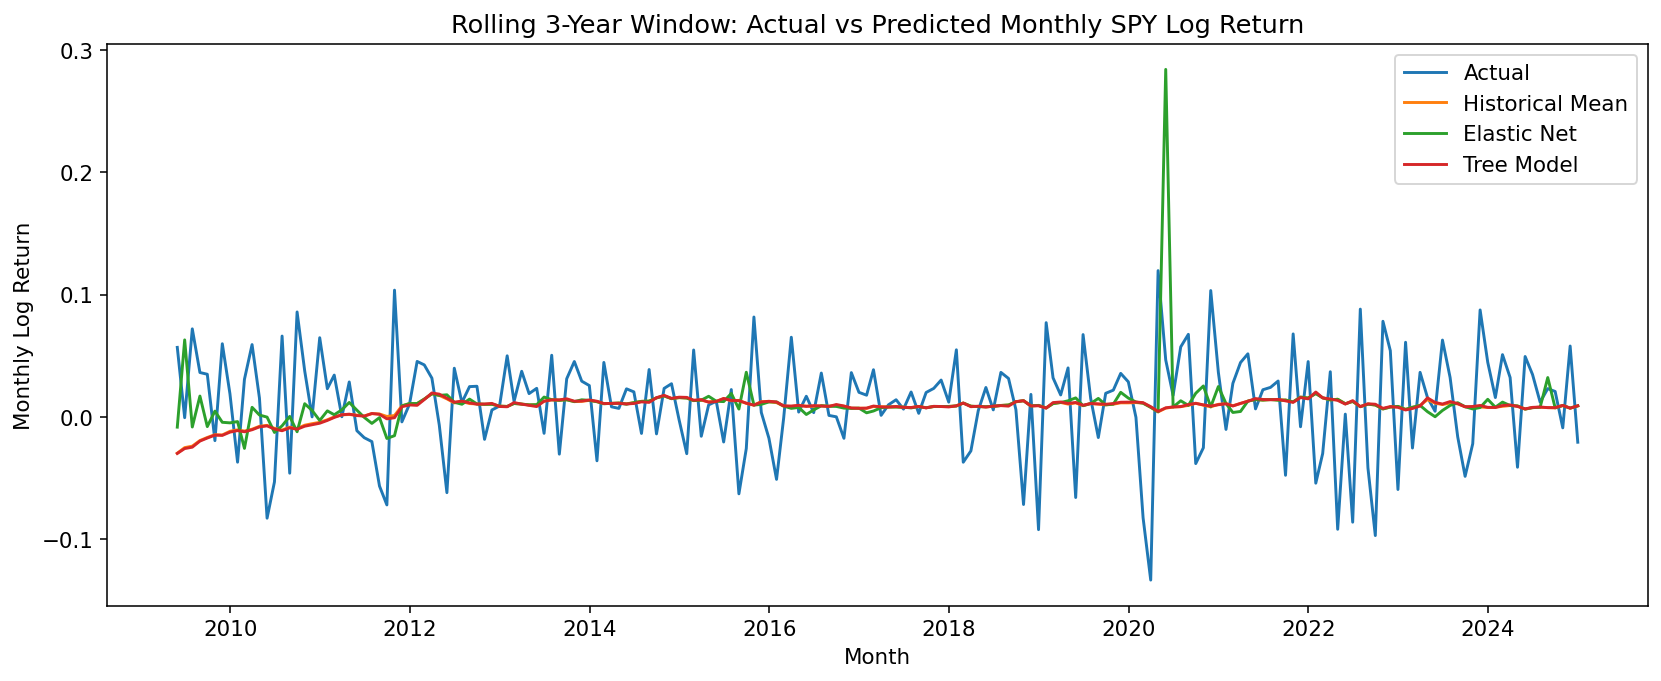

Saved: figures/rolling_predictions_actual_vs_models.png


In [ ]:
# CELL 6 — Actual vs predicted SPY return graph + recession shading

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import os


recessions = [
    ("2007-12-01", "2009-06-30"),  # Great Recession
    ("2020-02-01", "2020-04-30"),  # COVID recession
]

plt.figure(figsize=(12, 5))

plt.plot(
    rolling_preds["month_end"],
    rolling_preds["actual"],
    label="Actual",
    linewidth=2
)

plt.plot(
    rolling_preds["month_end"],
    rolling_preds["pred_mean"],
    label="Historical Mean",
    alpha=0.8
)

plt.plot(
    rolling_preds["month_end"],
    rolling_preds["pred_enet"],
    label="Elastic Net",
    alpha=0.9
)

plt.plot(
    rolling_preds["month_end"],
    rolling_preds["pred_tree"],
    label="Tree Model",
    alpha=0.9
)

# Add recession shading + labels
for i, (start, end) in enumerate(recessions):

    start = pd.to_datetime(start)
    end = pd.to_datetime(end)

    plt.axvspan(
        start,
        end,
        color="gray",
        alpha=0.2,
        label="NBER Recession" if i == 0 else None
    )

    midpoint = start + (end - start) / 2

    plt.text(
        midpoint,
        plt.ylim()[1] * 0.9,
        "Recession",
        ha="center",
        va="top",
        fontsize=9,
        rotation=90,
        color="black"
    )

# Formatting
plt.title("Rolling 3-Year Window: Actual vs Predicted Monthly SPY Log Return")
plt.xlabel("Month")
plt.ylabel("Monthly Log Return")

plt.gca().xaxis.set_major_locator(mdates.YearLocator(2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.legend()
plt.tight_layout()

outpath = os.path.join(
    OUTDIR,
    "rolling_predictions_actual_vs_models_recessions.png"
)

plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", outpath)

In [9]:
# CELL 7 — Set up readable feature labels
# This cell is for convenience only as graphs can become unreadable without the "prettified" names

pretty_names = {
    "mom_3m_log_lag1": "3-Month Momentum",
    "vix_m_lag1": "VIX Level",
    "log_vix_m_lag1": "Log VIX",
    "fxi_log_ret_m_lag1": "China Equity Returns (FXI)",
    "oil_log_ret_m_lag1": "Oil Returns",
    "fomc_hawk_proxy_m_lag1": "FOMC Hawkishness",
    "cpi_yoy_pct_lag1": "Inflation (CPI YoY)",
    "unrate_lag1": "Unemployment Rate",
    "dgs10_lag1": "10Y Treasury Yield",
    "pmi_lag1": "Manufacturing PMI",
}

def pretty_feature_name(x):
    return pretty_names.get(x, x)

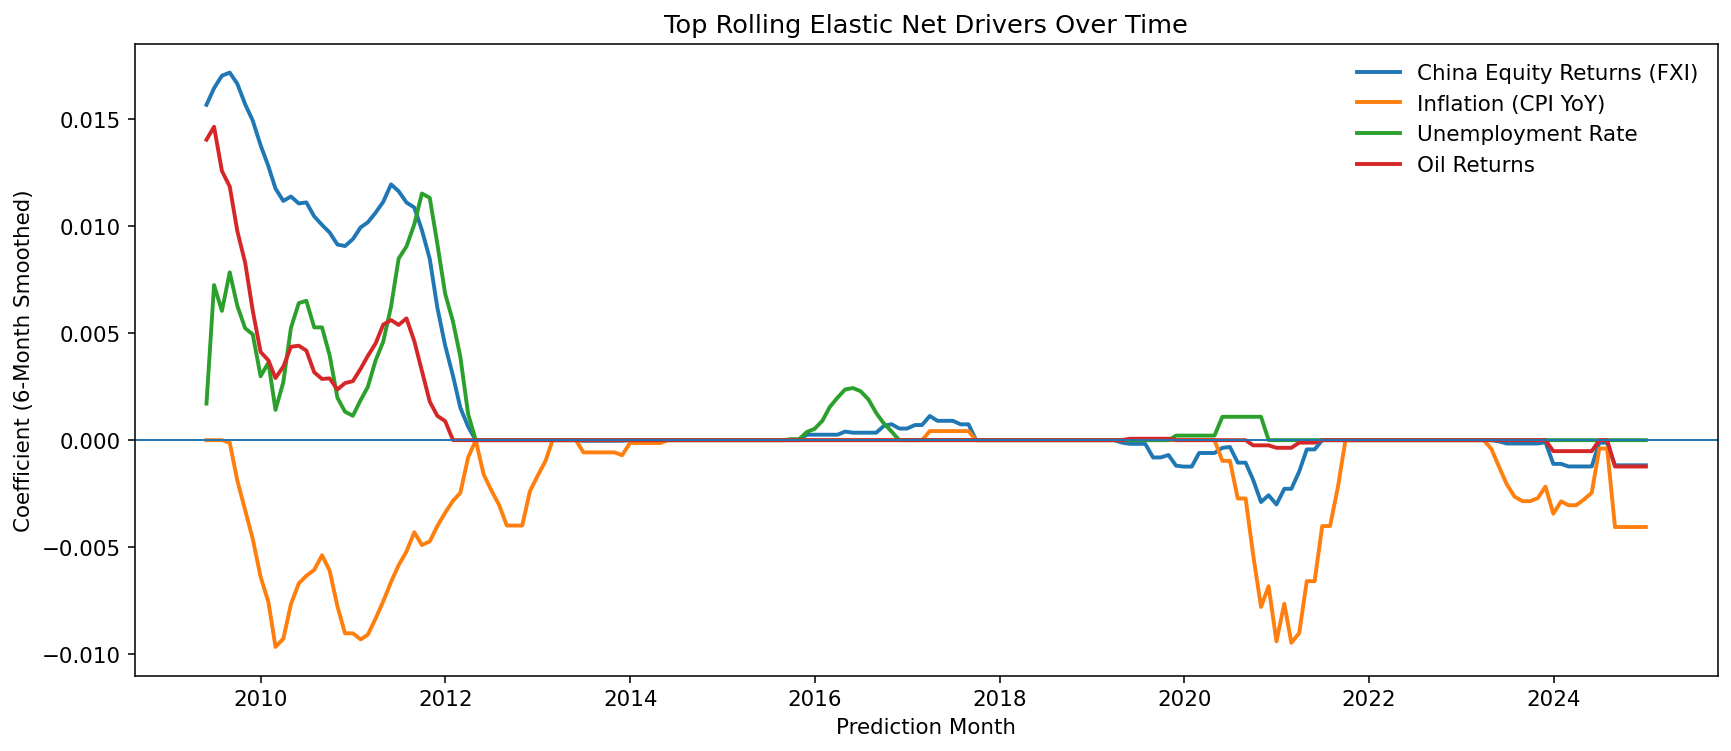

Saved: figures/rolling_enet_top_drivers_lines.png


In [9]:
# CELL 8 — Top Elastic Net drivers over time (line plot)

coef_plot = coef_df.copy()

if len(coef_plot) > 0:
    coef_plot["month_end"] = pd.to_datetime(coef_plot["month_end"])
    coef_plot = coef_plot.sort_values("month_end").set_index("month_end")

    coef_features = [c for c in feature_cols if c in coef_plot.columns]
    coef_features = [
        c for c in coef_features
        if coef_plot[c].notna().sum() > 0 and coef_plot[c].abs().sum() > 0
    ]

    coef_mat = coef_plot[coef_features].copy()

    # Smooth to reduce noise
    coef_smooth = coef_mat.rolling(window=6, min_periods=1).mean()

    # We choose the top 4 most important features overall
    top_features = (
        coef_smooth.abs().mean()
        .sort_values(ascending=False)
        .head(4)
        .index.tolist()
    )

    plt.figure(figsize=(12.5, 5.5))

    for f in top_features:
        plt.plot(
            coef_smooth.index,
            coef_smooth[f],
            linewidth=2,
            label=pretty_feature_name(f)
        )

    plt.axhline(0, linewidth=1)
    plt.title("Top Rolling Elastic Net Drivers Over Time")
    plt.xlabel("Prediction Month")
    plt.ylabel("Coefficient (6-Month Smoothed)")
    plt.legend(frameon=False)
    plt.tight_layout()

    outpath = os.path.join(OUTDIR, "rolling_enet_top_drivers_lines.png")
    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", outpath)
else:
    print("No coefficient data available.")

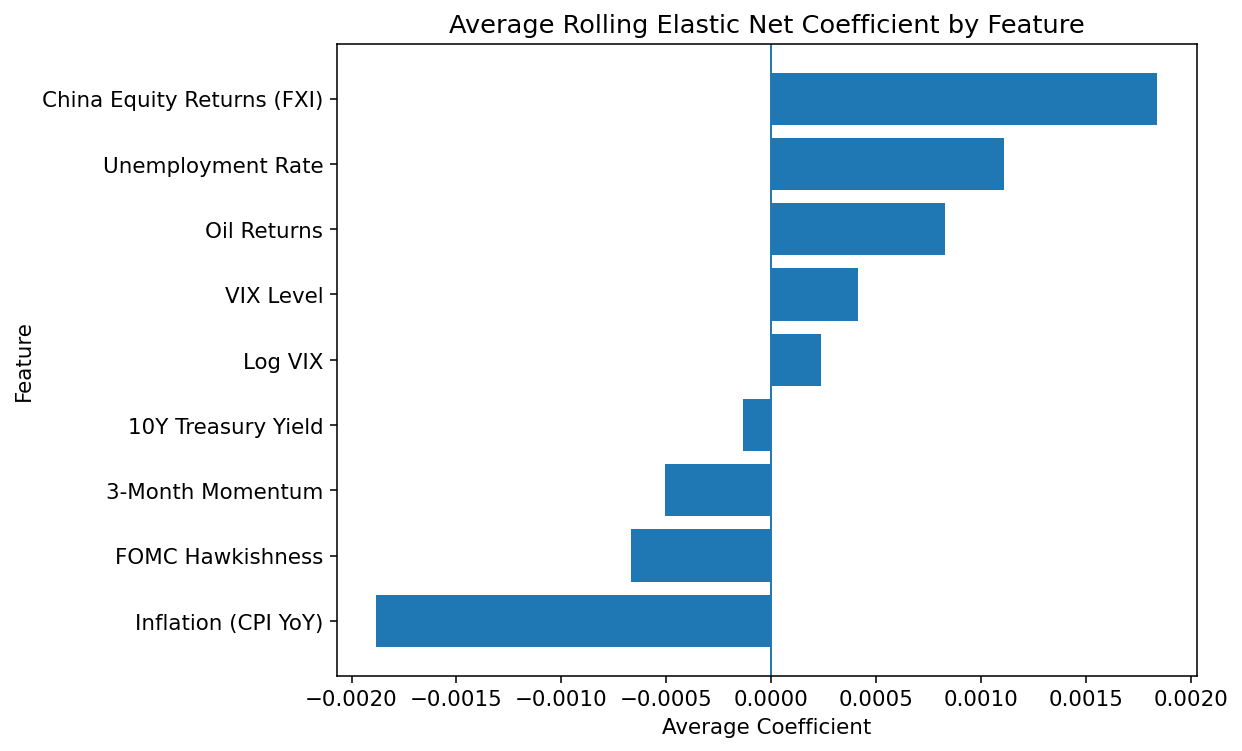

Saved: figures/rolling_enet_avg_coefficient_bar.png


In [10]:

# CELL 9 — Average coefficient by feature (bar chart)

coef_plot = coef_df.copy()

if len(coef_plot) > 0:
    coef_plot["month_end"] = pd.to_datetime(coef_plot["month_end"])
    coef_plot = coef_plot.sort_values("month_end").set_index("month_end")

    coef_features = [c for c in feature_cols if c in coef_plot.columns]
    coef_features = [
        c for c in coef_features
        if coef_plot[c].notna().sum() > 0 and coef_plot[c].abs().sum() > 0
    ]

    coef_smooth = coef_plot[coef_features].rolling(window=6, min_periods=1).mean()

    avg_coef = coef_smooth.mean().sort_values()
    labels = [pretty_feature_name(x) for x in avg_coef.index]

    plt.figure(figsize=(9, 5.5))
    plt.barh(labels, avg_coef.values)
    plt.axvline(0, linewidth=1)
    plt.title("Average Rolling Elastic Net Coefficient by Feature")
    plt.xlabel("Average Coefficient")
    plt.ylabel("Feature")
    plt.tight_layout()

    outpath = os.path.join(OUTDIR, "rolling_enet_avg_coefficient_bar.png")
    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", outpath)
else:
    print("No coefficient data available.")

In [11]:
# Cell 10 - Rolling-window backtest for SPY return modeling

if not HAS_XGB:
    from sklearn.ensemble import RandomForestRegressor

def sign_accuracy(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(np.sign(y_true) == np.sign(y_pred))

def metric_block(actual, pred):
    mask = pd.notna(actual) & pd.notna(pred)
    y = np.asarray(actual[mask])
    p = np.asarray(pred[mask])

    return {
        "RMSE": float(np.sqrt(mean_squared_error(y, p))),
        "MAE": float(mean_absolute_error(y, p)),
        "Directional_Accuracy": float(sign_accuracy(y, p)),
        "N_Predictions": int(len(y))
    }

def clip_pred(x, lower=-0.15, upper=0.15):
    return float(np.clip(x, lower, upper))

def run_rolling_models(
    df,
    feature_cols,
    target_col="spy_log_ret_m",
    window=36,
    min_nonmissing_features=3,
    enet_l1_ratio=(0.5, 0.7, 0.9),
    enet_alphas=None,
    xgb_params=None,
    clip_bounds=(-0.15, 0.15),
):
    """
    Runs the rolling backtest for:
      - historical mean
      - momentum-only linear regression
      - rolling Elastic Net
      - rolling tree model (XGBoost if available, else RandomForest)

    Returns a dict with:
      - rolling_preds
      - coef_df
      - metrics_df
    """

    if enet_alphas is None:
        enet_alphas = np.logspace(-2, 0.5, 25)

    if xgb_params is None:
        xgb_params = {
            "n_estimators": 400,
            "max_depth": 4,
            "learning_rate": 0.03,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "reg_alpha": 0.1,
            "reg_lambda": 1.0,
            "min_child_weight": 3,
            "gamma": 0.1,
            "random_state": 42,
            "n_jobs": 4,
        }

    results = []
    coef_rows = []

    # make sure sorted
    df = df.copy()
    df["month_end"] = pd.to_datetime(df["month_end"])
    df = df.sort_values("month_end").reset_index(drop=True)

    for t in range(window, len(df)):
        train = df.iloc[t-window:t].copy()
        test = df.iloc[[t]].copy()

        usable = []
        for c in feature_cols:
            if train[c].notna().sum() >= min_nonmissing_features:
                usable.append(c)

        if len(usable) == 0:
            continue

        train_full = train.dropna(subset=usable).copy()
        test_full = test.dropna(subset=usable).copy()

        if len(test_full) == 0:
            continue

        if len(train_full) < 18:
            continue

        X_train = train_full[usable]
        y_train = train_full[target_col].values
        X_test = test_full[usable]
        y_test = test_full[target_col].values[0]

        pred_dict = {
            "month_end": test_full["month_end"].iloc[0],
            "actual": y_test,
        }

        # 1) Historical mean baseline
        pred_dict["pred_mean"] = float(np.mean(y_train))

        # 2) Momentum-only baseline
        if "mom_3m_log_lag1" in usable:
            lr_mom = LinearRegression()
            lr_mom.fit(train_full[["mom_3m_log_lag1"]], y_train)
            pred_dict["pred_mom_lr"] = float(
                lr_mom.predict(test_full[["mom_3m_log_lag1"]])[0]
            )
        else:
            pred_dict["pred_mom_lr"] = np.nan

        # 3) Rolling Elastic Net
        n_train = len(train_full)
        n_splits = min(3, max(2, n_train // 10))

        enet_pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("enet", ElasticNetCV(
                l1_ratio=list(enet_l1_ratio),
                alphas=np.array(enet_alphas),
                cv=TimeSeriesSplit(n_splits=n_splits),
                max_iter=50000,
                tol=1e-4,
                random_state=42
            ))
        ])

        enet_pipe.fit(X_train, y_train)
        pred_dict["pred_enet"] = clip_pred(
            enet_pipe.predict(X_test)[0],
            lower=clip_bounds[0],
            upper=clip_bounds[1]
        )

        enet_model = enet_pipe.named_steps["enet"]
        coef_map = {"month_end": test_full["month_end"].iloc[0]}
        for f, coef in zip(usable, enet_model.coef_):
            coef_map[f] = coef
        coef_rows.append(coef_map)

        # 4) Rolling tree model
        if HAS_XGB:
            tree_model = xgb.XGBRegressor(**xgb_params)
        else:
            tree_model = RandomForestRegressor(
                n_estimators=300,
                max_depth=6,
                random_state=42,
                n_jobs=4
            )

        tree_model.fit(X_train, y_train)
        pred_dict["pred_tree"] = clip_pred(
            tree_model.predict(X_test)[0],
            lower=clip_bounds[0],
            upper=clip_bounds[1]
        )

        results.append(pred_dict)

    # build outputs
    rolling_preds = pd.DataFrame(results)
    if len(rolling_preds) > 0:
        rolling_preds = rolling_preds.sort_values("month_end").reset_index(drop=True)

    coef_df = pd.DataFrame(coef_rows)
    if len(coef_df) > 0:
        coef_df = coef_df.sort_values("month_end").reset_index(drop=True)

    metric_rows = []
    if len(rolling_preds) > 0:
        for col, label in [
            ("pred_mean", "Historical Mean"),
            ("pred_mom_lr", "Momentum-only LR"),
            ("pred_enet", "Rolling Elastic Net"),
            ("pred_tree", "Rolling Tree Model"),
        ]:
            m = metric_block(rolling_preds["actual"], rolling_preds[col])
            m["Model"] = label
            metric_rows.append(m)

    metrics_df = pd.DataFrame(metric_rows)
    if len(metrics_df) > 0:
        metrics_df = metrics_df[
            ["Model", "RMSE", "MAE", "Directional_Accuracy", "N_Predictions"]
        ].sort_values("RMSE").reset_index(drop=True)

    return {
        "rolling_preds": rolling_preds,
        "coef_df": coef_df,
        "metrics_df": metrics_df,
    }

In [ ]:
# Cell 11 - Set up tuning harness for Elastic Net hyperparameters

# Scoring function to prioritize model choice, first version is prioritizing highest directional accuracy

# def score_enet(metrics_df):
#     row = metrics_df.loc[metrics_df["Model"] == "Rolling Elastic Net"].iloc[0]
#     return (
#         2.0 * row["Directional_Accuracy"]
#         - 1.0 * row["RMSE"]
#         - 0.5 * row["MAE"]
#     )

def score_enet(metrics_df):
    row = metrics_df.loc[
        metrics_df["Model"] == "Rolling Elastic Net"
    ].iloc[0]

    return (
        0.5 * row["Directional_Accuracy"]
        - 8.0 * row["RMSE"]
        - 2.0 * row["MAE"]
    )

def run_tuning(
    df,
    feature_cols,
    target_col,
    window_choices,
    l1_ratio_choices,
    alpha_choices,
    min_nonmissing_choices=(3,),
    xgb_param_choices=None,
):
    if xgb_param_choices is None:
        xgb_param_choices = [{
            "n_estimators": 400,
            "max_depth": 4,
            "learning_rate": 0.03,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "reg_alpha": 0.1,
            "reg_lambda": 1.0,
            "min_child_weight": 3,
            "gamma": 0.1,
            "random_state": 42,
            "n_jobs": 4,
        }]

    results = []
    artifacts = {}
    config_id = 0

    for window, min_nonmissing, l1_ratio, alphas, xgb_params in itertools.product(
        window_choices,
        min_nonmissing_choices,
        l1_ratio_choices,
        alpha_choices,
        xgb_param_choices
    ):
        config_id += 1
        print(f"Running config {config_id}...")

        result = run_rolling_models(
            df=df,
            feature_cols=feature_cols,
            target_col=target_col,
            window=window,
            min_nonmissing_features=min_nonmissing,
            enet_l1_ratio=l1_ratio,
            enet_alphas=alphas,
            xgb_params=xgb_params,
        )

        metrics_df = result["metrics_df"]
        enet_row = metrics_df.loc[
            metrics_df["Model"] == "Rolling Elastic Net"
        ].iloc[0]

        row = {
            "config_id": config_id,
            "window": window,
            "min_nonmissing_features": min_nonmissing,
            "l1_ratio": tuple(l1_ratio),
            "alpha_min": float(np.min(alphas)),
            "alpha_max": float(np.max(alphas)),
            "alpha_n": len(alphas),
            "RMSE": enet_row["RMSE"],
            "MAE": enet_row["MAE"],
            "Directional_Accuracy": enet_row["Directional_Accuracy"],
            "score": score_enet(metrics_df),
        }

        results.append(row)
        artifacts[config_id] = result

    tuning_df = pd.DataFrame(results).sort_values(
        ["score", "Directional_Accuracy", "RMSE"],
        ascending=[False, False, True]
    ).reset_index(drop=True)

    return tuning_df, artifacts

In [13]:
# Cell 12 - Find best hyperparameter config for Elastic Net based on our scoring function, and extract the metrics for the chosen model 

window_choices = [30, 36, 42]

l1_ratio_choices = [
    (0.4, 0.6, 0.8),
    (0.5, 0.7, 0.9),
    (0.6, 0.8, 1.0),
]

alpha_choices = [
    np.logspace(-2.5, 0.5, 30),   
    np.logspace(-2, 0.3, 25),     
    np.logspace(-1.5, 0.2, 20),  
]

xgb_param_choices = [
    {
        "n_estimators": 300,
        "max_depth": 3,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "reg_alpha": 0.1,
        "reg_lambda": 1.0,
        "min_child_weight": 3,
        "gamma": 0.1,
        "random_state": 42,
        "n_jobs": 4,
    },
    {
        "n_estimators": 500,
        "max_depth": 4,
        "learning_rate": 0.02,
        "subsample": 0.7,
        "colsample_bytree": 0.7,
        "reg_alpha": 0.2,
        "reg_lambda": 1.5,
        "min_child_weight": 5,
        "gamma": 0.2,
        "random_state": 42,
        "n_jobs": 4,
    },
]

tuning_df, artifacts = run_tuning(
    df=df,
    feature_cols=feature_cols,
    target_col=target_col,
    window_choices=[30, 36, 42],
    l1_ratio_choices=[
        (0.4, 0.6, 0.8),
        (0.5, 0.7, 0.9),
        (0.6, 0.8, 1.0),
    ],
    alpha_choices=[
        np.logspace(-2.5, 0.5, 30),
        np.logspace(-2, 0.3, 25),
        np.logspace(-1.5, 0.2, 20),
    ],
    min_nonmissing_choices=[2, 3, 4],
    xgb_param_choices=xgb_param_choices,
)

print(tuning_df.head())

best_id = tuning_df.iloc[0]["config_id"]
best_result = artifacts[best_id]

rolling_preds = best_result["rolling_preds"]
coef_df = best_result["coef_df"]
metrics_df = best_result["metrics_df"]

print(metrics_df)
tuning_df.groupby("window")["Directional_Accuracy"].mean()

Running config 1...
Running config 2...
Running config 3...
Running config 4...
Running config 5...
Running config 6...
Running config 7...
Running config 8...
Running config 9...
Running config 10...
Running config 11...
Running config 12...
Running config 13...
Running config 14...
Running config 15...
Running config 16...
Running config 17...
Running config 18...
Running config 19...
Running config 20...
Running config 21...
Running config 22...
Running config 23...
Running config 24...
Running config 25...
Running config 26...
Running config 27...
Running config 28...
Running config 29...
Running config 30...
Running config 31...
Running config 32...
Running config 33...
Running config 34...
Running config 35...
Running config 36...
Running config 37...
Running config 38...
Running config 39...
Running config 40...
Running config 41...
Running config 42...
Running config 43...
Running config 44...
Running config 45...
Running config 46...
Running config 47...
Running config 48...
R

window
30    0.621998
36    0.658997
42    0.642435
Name: Directional_Accuracy, dtype: float64

Saved CSVs:
- figures/tuning_results.csv
- figures/best_model_metrics.csv
- figures/best_model_predictions.csv
- figures/best_model_coefficients.csv
Saved: figures/top_tuning_configs_table.png


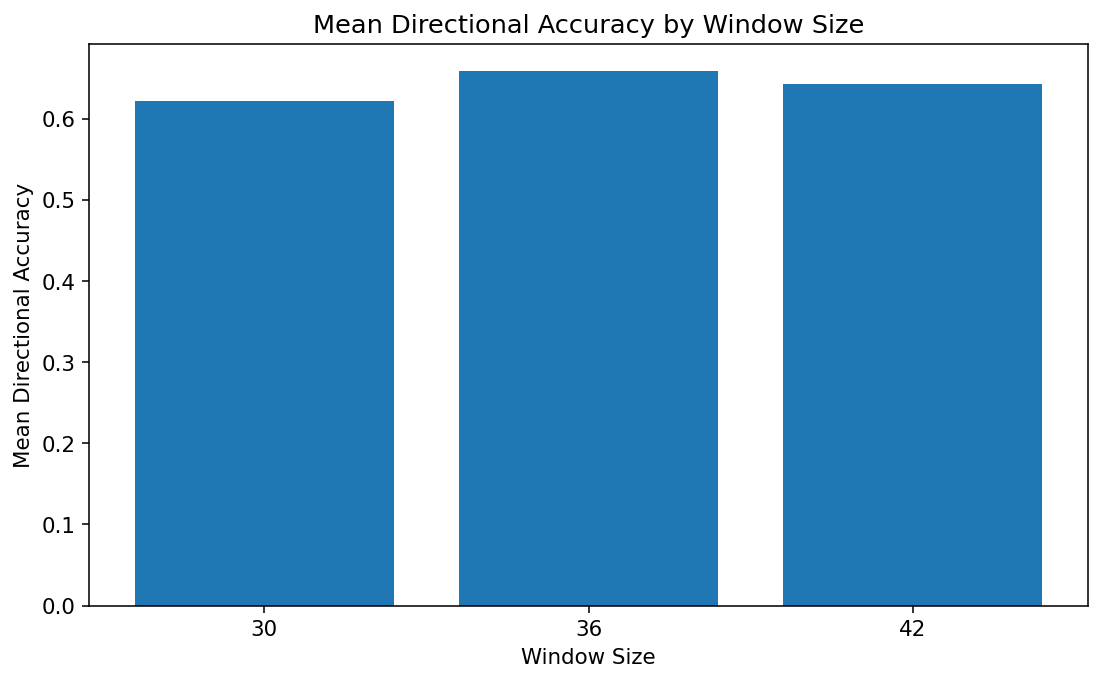

Saved: figures/tuning_window_mean_directional_accuracy.png


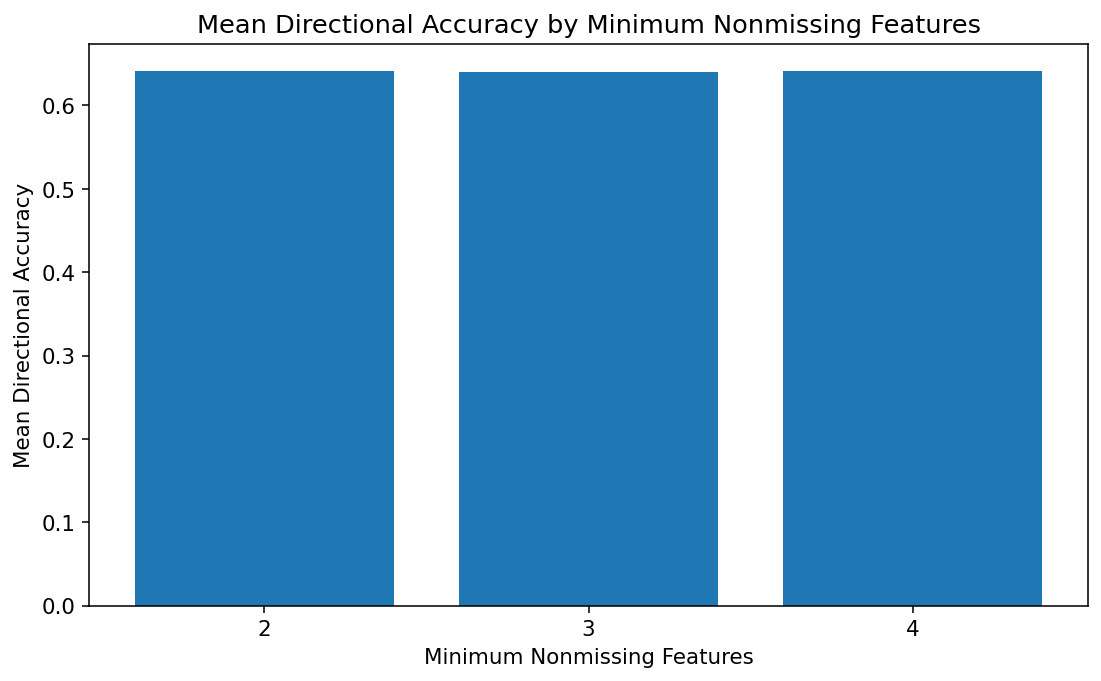

Saved: figures/tuning_min_nonmissing_mean_directional_accuracy.png


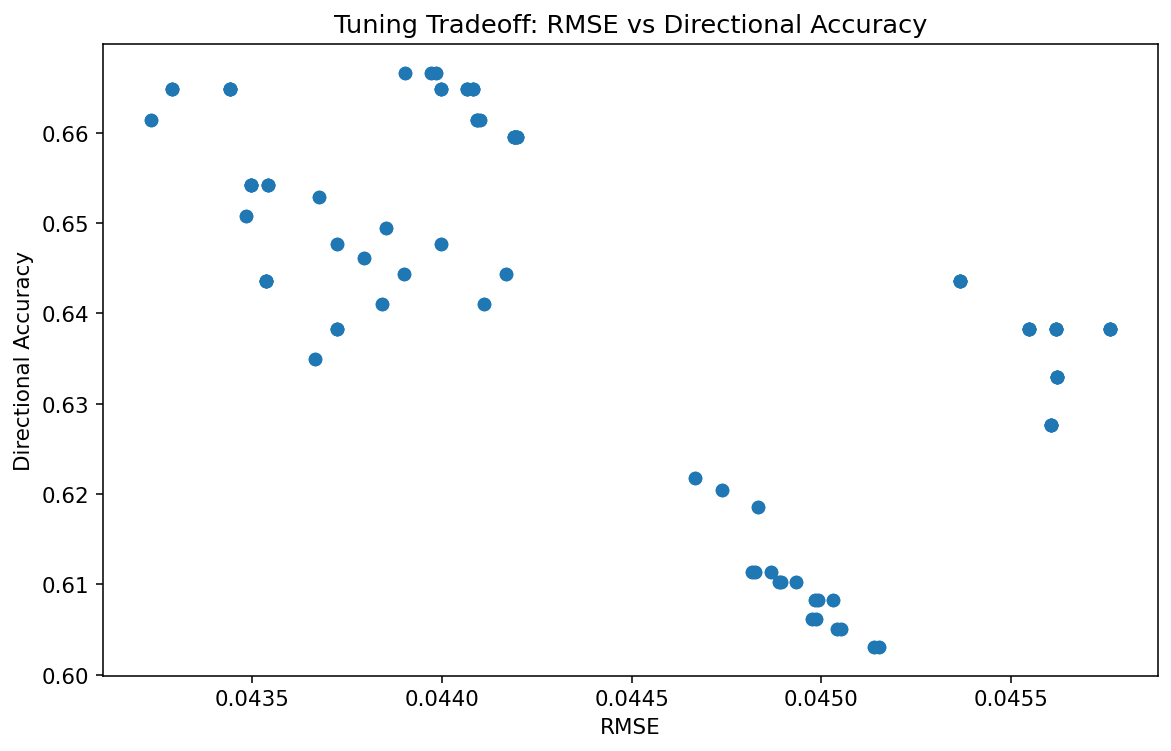

Saved: figures/tuning_rmse_vs_directional_accuracy.png


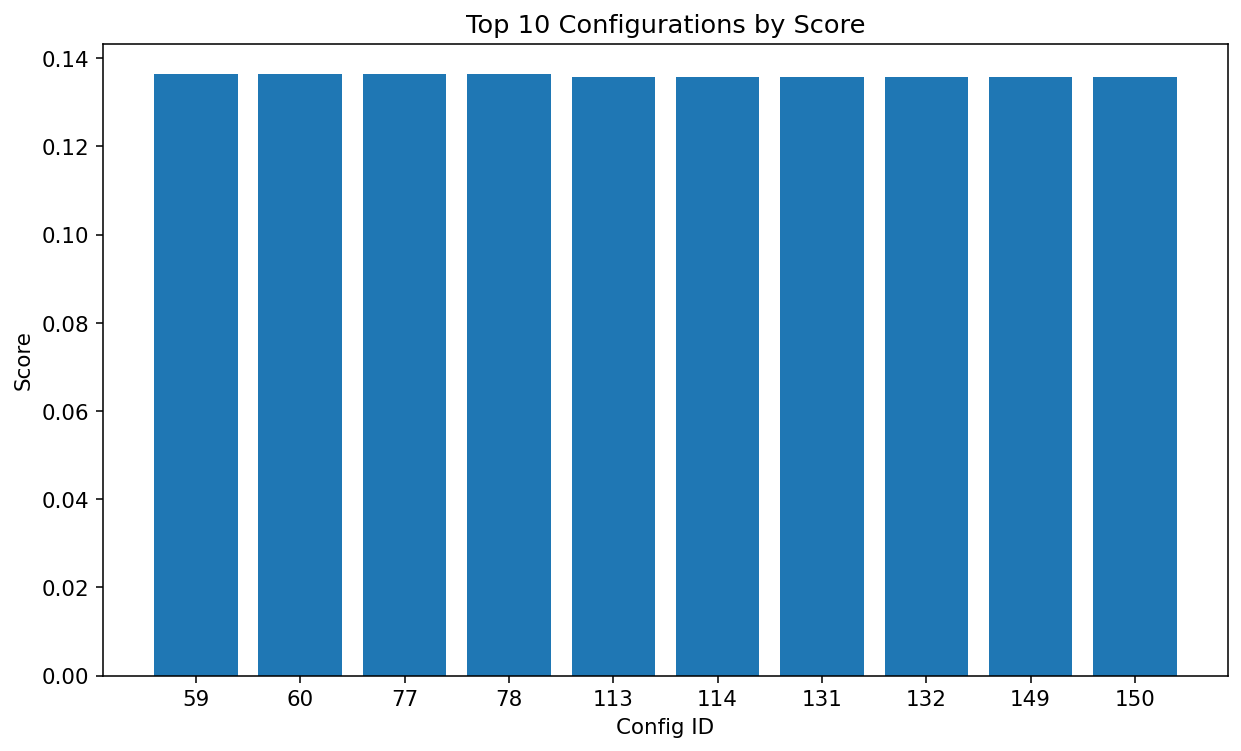

Saved: figures/top10_configs_by_score.png


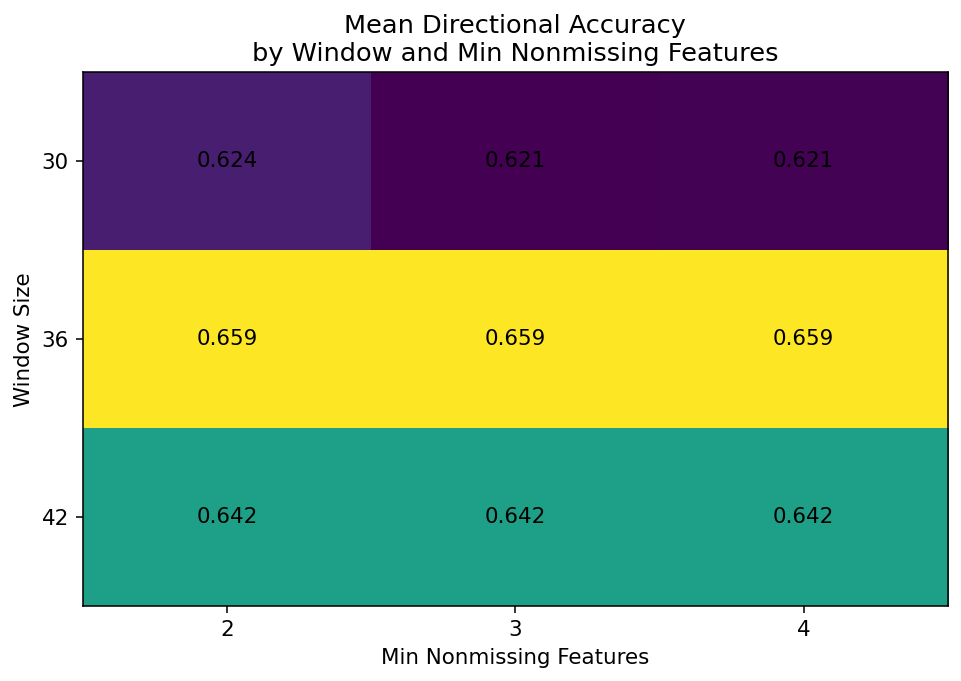

Saved: figures/heatmap_window_vs_min_nonmissing_da.png
Saved: figures/best_model_metrics_table.png


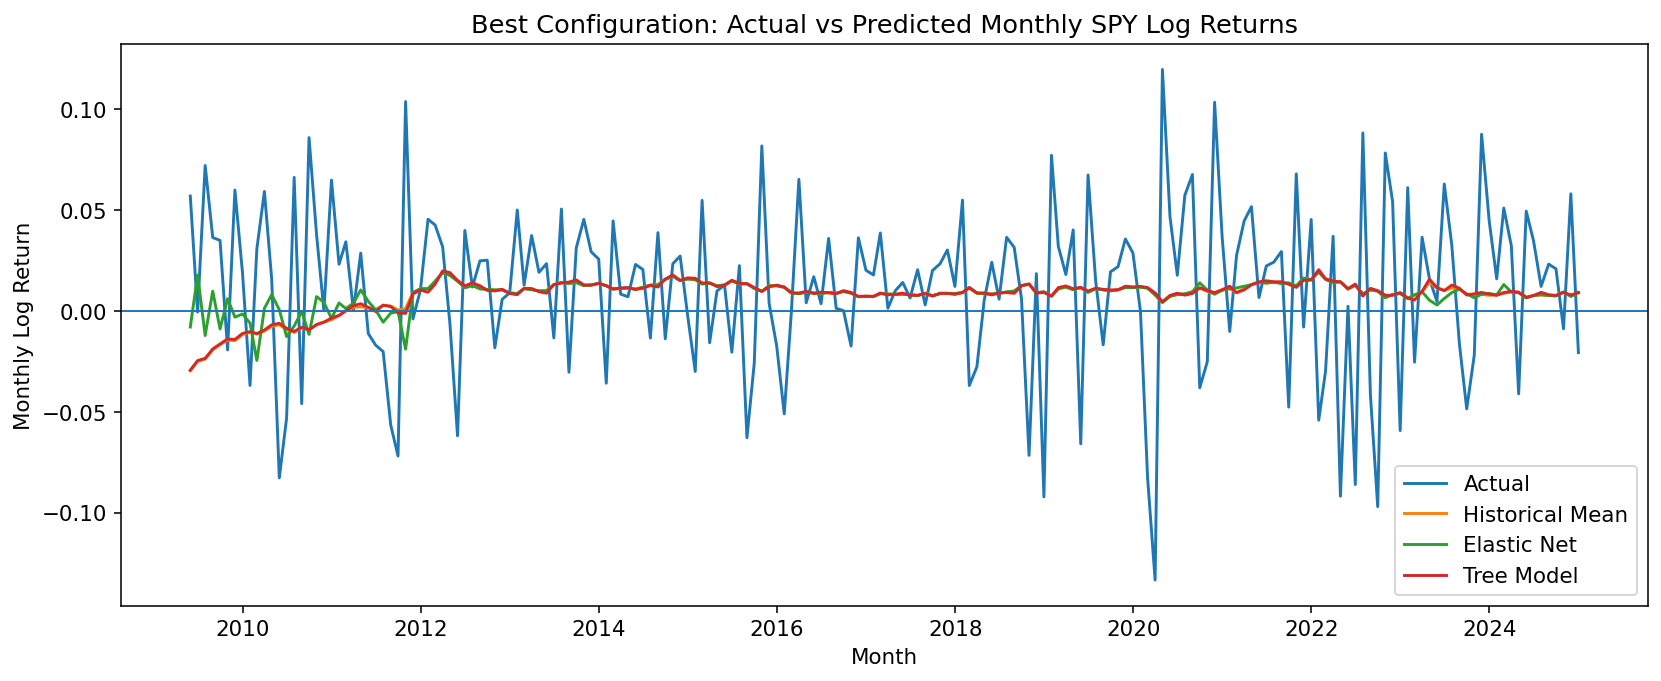

Saved: figures/best_config_actual_vs_predicted.png


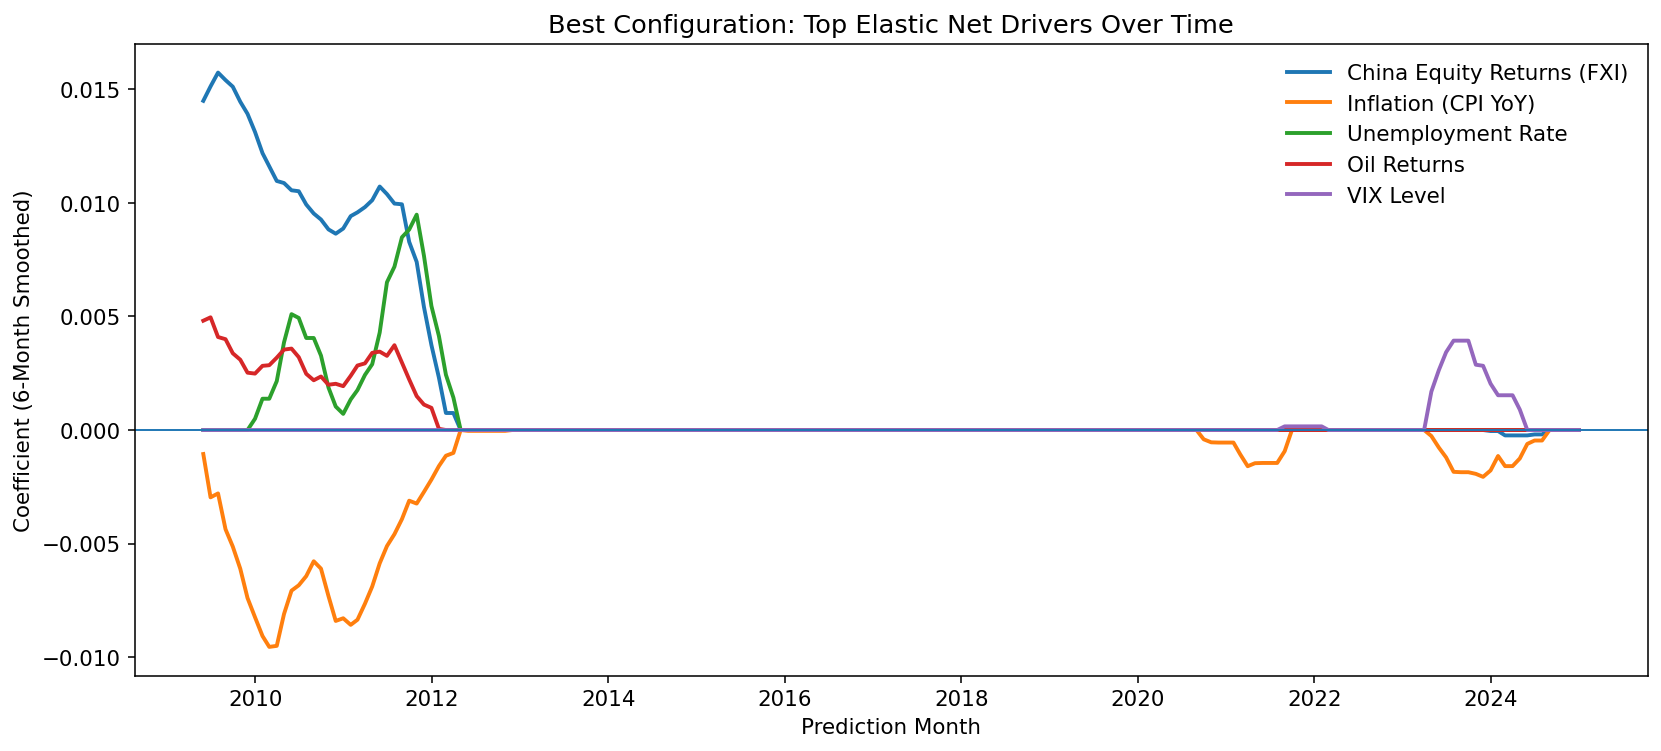

Saved: figures/best_config_top_enet_drivers.png


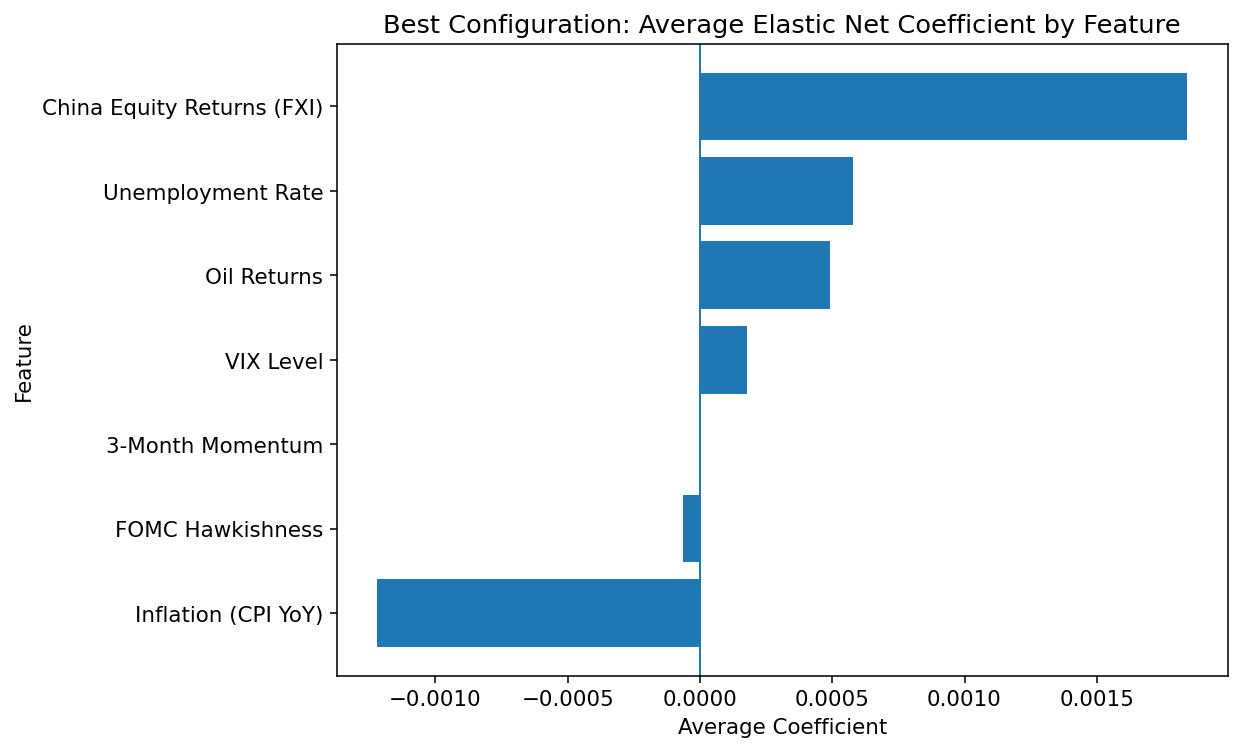

Saved: figures/best_config_avg_enet_coefficients.png
Done.


In [16]:
# Cell 13 - Save results to figures


# 1) Save raw result tables

tuning_df.to_csv(os.path.join(OUTDIR, "tuning_results.csv"), index=False)
metrics_df.to_csv(os.path.join(OUTDIR, "best_model_metrics.csv"), index=False)
rolling_preds.to_csv(os.path.join(OUTDIR, "best_model_predictions.csv"), index=False)
coef_df.to_csv(os.path.join(OUTDIR, "best_model_coefficients.csv"), index=False)

print("Saved CSVs:")
print("-", os.path.join(OUTDIR, "tuning_results.csv"))
print("-", os.path.join(OUTDIR, "best_model_metrics.csv"))
print("-", os.path.join(OUTDIR, "best_model_predictions.csv"))
print("-", os.path.join(OUTDIR, "best_model_coefficients.csv"))


# 2) Helper for saving tables as PNG
def save_table_png(df, title, path, max_rows=12):
    show = df.head(max_rows).copy()

    for c in show.columns:
        if pd.api.types.is_float_dtype(show[c]):
            show[c] = show[c].map(lambda x: f"{x:.4f}")
        else:
            show[c] = show[c].astype(str)

    fig, ax = plt.subplots(figsize=(12, 0.6 * len(show) + 1.5))
    ax.axis("off")
    ax.set_title(title, pad=10, fontsize=13, fontweight="bold")

    tbl = ax.table(
        cellText=show.values,
        colLabels=list(show.columns),
        cellLoc="center",
        loc="center"
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 1.3)

    fig.tight_layout()
    fig.savefig(path, dpi=500, bbox_inches="tight")
    plt.close(fig)
    print("Saved:", path)


# 3) Save top tuning configs table
top_cols = [
    "config_id", "window", "min_nonmissing_features", "l1_ratio",
    "alpha_min", "alpha_max", "alpha_n",
    "RMSE", "MAE", "Directional_Accuracy", "score"
]
save_table_png(
    tuning_df[top_cols],
    "Top Tuning Configurations",
    os.path.join(OUTDIR, "top_tuning_configs_table.png"),
    max_rows=10
)


# 4) Window comparison plot
window_summary = (
    tuning_df.groupby("window", as_index=False)
    .agg(
        mean_da=("Directional_Accuracy", "mean"),
        mean_rmse=("RMSE", "mean"),
        best_da=("Directional_Accuracy", "max"),
        best_rmse=("RMSE", "min")
    )
    .sort_values("window")
)

plt.figure(figsize=(8, 5))
plt.bar(window_summary["window"].astype(str), window_summary["mean_da"])
plt.title("Mean Directional Accuracy by Window Size")
plt.xlabel("Window Size")
plt.ylabel("Mean Directional Accuracy")
plt.tight_layout()

path = os.path.join(OUTDIR, "tuning_window_mean_directional_accuracy.png")
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", path)

window_summary.to_csv(os.path.join(OUTDIR, "window_summary.csv"), index=False)


# 5) Min nonmissing comparison plot
mn_summary = (
    tuning_df.groupby("min_nonmissing_features", as_index=False)
    .agg(
        mean_da=("Directional_Accuracy", "mean"),
        mean_rmse=("RMSE", "mean"),
        best_da=("Directional_Accuracy", "max"),
        best_rmse=("RMSE", "min")
    )
    .sort_values("min_nonmissing_features")
)

plt.figure(figsize=(8, 5))
plt.bar(mn_summary["min_nonmissing_features"].astype(str), mn_summary["mean_da"])
plt.title("Mean Directional Accuracy by Minimum Nonmissing Features")
plt.xlabel("Minimum Nonmissing Features")
plt.ylabel("Mean Directional Accuracy")
plt.tight_layout()

path = os.path.join(OUTDIR, "tuning_min_nonmissing_mean_directional_accuracy.png")
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", path)

mn_summary.to_csv(os.path.join(OUTDIR, "min_nonmissing_summary.csv"), index=False)


# 6) RMSE vs Directional Accuracy scatterplot
plt.figure(figsize=(8.5, 5.5))
plt.scatter(tuning_df["RMSE"], tuning_df["Directional_Accuracy"])
plt.title("Tuning Tradeoff: RMSE vs Directional Accuracy")
plt.xlabel("RMSE")
plt.ylabel("Directional Accuracy")
plt.tight_layout()

path = os.path.join(OUTDIR, "tuning_rmse_vs_directional_accuracy.png")
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", path)


# 7) Top 10 configs by score
top10 = tuning_df.head(10).copy()
top10["label"] = top10["config_id"].astype(str)

plt.figure(figsize=(9, 5.5))
plt.bar(top10["label"], top10["score"])
plt.title("Top 10 Configurations by Score")
plt.xlabel("Config ID")
plt.ylabel("Score")
plt.tight_layout()

path = os.path.join(OUTDIR, "top10_configs_by_score.png")
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", path)


# 8) Heatmap-like table: window x min_nonmissing
pivot_da = tuning_df.pivot_table(
    index="window",
    columns="min_nonmissing_features",
    values="Directional_Accuracy",
    aggfunc="mean"
).sort_index()

plt.figure(figsize=(7, 5))
plt.imshow(pivot_da.values, aspect="auto")
plt.xticks(range(len(pivot_da.columns)), pivot_da.columns)
plt.yticks(range(len(pivot_da.index)), pivot_da.index)
plt.title("Mean Directional Accuracy\nby Window and Min Nonmissing Features")
plt.xlabel("Min Nonmissing Features")
plt.ylabel("Window Size")

for i in range(pivot_da.shape[0]):
    for j in range(pivot_da.shape[1]):
        val = pivot_da.iloc[i, j]
        if pd.notna(val):
            plt.text(j, i, f"{val:.3f}", ha="center", va="center")

plt.tight_layout()
path = os.path.join(OUTDIR, "heatmap_window_vs_min_nonmissing_da.png")
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", path)

pivot_da.to_csv(os.path.join(OUTDIR, "heatmap_window_vs_min_nonmissing_da.csv"))


# 10) Best model metrics table
save_table_png(
    metrics_df,
    "Best Configuration — Model Metrics",
    os.path.join(OUTDIR, "best_model_metrics_table.png"),
    max_rows=len(metrics_df)
)


# 11) Best model: actual vs predicted
plot_df = rolling_preds.copy()
plot_df["month_end"] = pd.to_datetime(plot_df["month_end"])

plt.figure(figsize=(12, 5))
plt.plot(plot_df["month_end"], plot_df["actual"], label="Actual")
plt.plot(plot_df["month_end"], plot_df["pred_mean"], label="Historical Mean")
plt.plot(plot_df["month_end"], plot_df["pred_enet"], label="Elastic Net")
plt.plot(plot_df["month_end"], plot_df["pred_tree"], label="Tree Model")
plt.axhline(0, linewidth=1)
plt.title("Best Configuration: Actual vs Predicted Monthly SPY Log Returns")
plt.xlabel("Month")
plt.ylabel("Monthly Log Return")
plt.legend()
plt.tight_layout()

path = os.path.join(OUTDIR, "best_config_actual_vs_predicted.png")
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", path)


# 12) Best model: coefficient plot
pretty_names = {
    "mom_3m_log_lag1": "3-Month Momentum",
    "vix_m_lag1": "VIX Level",
    "log_vix_m_lag1": "Log VIX",
    "fxi_log_ret_m_lag1": "China Equity Returns (FXI)",
    "oil_log_ret_m_lag1": "Oil Returns",
    "fomc_hawk_proxy_m_lag1": "FOMC Hawkishness",
    "cpi_yoy_pct_lag1": "Inflation (CPI YoY)",
    "unrate_lag1": "Unemployment Rate",
    "dgs10_lag1": "10Y Treasury Yield",
    "pmi_lag1": "Manufacturing PMI",
}

def pretty_feature_name(x):
    return pretty_names.get(x, x)

coef_plot = coef_df.copy()

if len(coef_plot) > 0:
    coef_plot["month_end"] = pd.to_datetime(coef_plot["month_end"])
    coef_plot = coef_plot.sort_values("month_end").set_index("month_end")

    coef_features = [c for c in feature_cols if c in coef_plot.columns]
    coef_features = [
        c for c in coef_features
        if coef_plot[c].notna().sum() > 0 and coef_plot[c].abs().sum() > 0
    ]

    if len(coef_features) > 0:
        coef_smooth = coef_plot[coef_features].rolling(window=6, min_periods=1).mean()

        top_features = (
            coef_smooth.abs().mean()
            .sort_values(ascending=False)
            .head(5)
            .index.tolist()
        )

        plt.figure(figsize=(12, 5.5))
        for f in top_features:
            plt.plot(
                coef_smooth.index,
                coef_smooth[f],
                linewidth=2,
                label=pretty_feature_name(f)
            )

        plt.axhline(0, linewidth=1)
        plt.title("Best Configuration: Top Elastic Net Drivers Over Time")
        plt.xlabel("Prediction Month")
        plt.ylabel("Coefficient (6-Month Smoothed)")
        plt.legend(frameon=False)
        plt.tight_layout()

        path = os.path.join(OUTDIR, "best_config_top_enet_drivers.png")
        plt.savefig(path, dpi=300, bbox_inches="tight")
        plt.show()
        print("Saved:", path)

        avg_coef = coef_smooth.mean().sort_values()
        labels = [pretty_feature_name(x) for x in avg_coef.index]

        plt.figure(figsize=(9, 5.5))
        plt.barh(labels, avg_coef.values)
        plt.axvline(0, linewidth=1)
        plt.title("Best Configuration: Average Elastic Net Coefficient by Feature")
        plt.xlabel("Average Coefficient")
        plt.ylabel("Feature")
        plt.tight_layout()

        path = os.path.join(OUTDIR, "best_config_avg_enet_coefficients.png")
        plt.savefig(path, dpi=300, bbox_inches="tight")
        plt.show()
        print("Saved:", path)

print("Done.")

In [15]:
# Cell 14 - Save metrics table as PNG

def save_table_png(df, title, path):
    show = df.copy()

    for c in show.columns:
        if pd.api.types.is_float_dtype(show[c]):
            show[c] = show[c].map(lambda x: f"{x:.4f}")

    fig, ax = plt.subplots(figsize=(10, 2.8))
    ax.axis("off")
    ax.set_title(title, pad=10, fontsize=13, fontweight="bold")

    tbl = ax.table(
        cellText=show.values,
        colLabels=list(show.columns),
        cellLoc="center",
        loc="center"
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 1.4)

    fig.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.close(fig)
    print("Saved:", path)

metrics_path = os.path.join(OUTDIR, "rolling_model_metrics_table.png")
save_table_png(metrics_df, "Out-of-Sample Performance — Rolling 3-Year Window", metrics_path)

Saved: figures/rolling_model_metrics_table.png


In [ ]:
# Cell 14 ARIMAX model + metrics + graphs 
# Added after feedback from course staff on time-series modeling

import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX


def directional_accuracy(y_true, y_pred):
    return np.mean(np.sign(y_true) == np.sign(y_pred))

def metric_block(actual, pred):
    mask = pd.notna(actual) & pd.notna(pred)
    y = np.asarray(actual[mask])
    p = np.asarray(pred[mask])

    return {
        "RMSE": np.sqrt(mean_squared_error(y, p)),
        "MAE": mean_absolute_error(y, p),
        "Directional_Accuracy": directional_accuracy(y, p),
        "R2": r2_score(y, p),
        "N_Predictions": len(y)
    }

def run_arimax(data, target_col, feature_set, window_size, order, mode="expanding", clip_mult=3.0):
    rows = []

    for t in range(window_size, len(data)):

        train = data.iloc[:t].copy() if mode == "expanding" else data.iloc[t-window_size:t].copy()
        test = data.iloc[[t]].copy()

        usable = [
            c for c in feature_set
            if c in train.columns
            and train[c].notna().sum() >= max(12, int(0.7 * min(window_size, len(train))))
            and test[c].notna().all()
        ]

        train_full = train.dropna(subset=[target_col] + usable).copy()
        test_full = test.dropna(subset=usable).copy()

        if len(train_full) < max(24, int(0.7 * window_size)) or len(test_full) == 0:
            continue

        y_train = train_full[target_col].astype(float)
        y_test = float(test_full[target_col].iloc[0])

        pred_mean = float(y_train.mean())

        try:
            if len(usable) > 0:
                scaler = StandardScaler()
                X_train = scaler.fit_transform(train_full[usable].astype(float))
                X_test = scaler.transform(test_full[usable].astype(float))
            else:
                X_train = None
                X_test = None

            model = SARIMAX(
                y_train,
                exog=X_train,
                order=order,
                trend="c",
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            fit = model.fit(
                disp=False,
                method="powell",
                maxiter=50
            )

            pred = float(fit.forecast(steps=1, exog=X_test).iloc[0])

            clip_bound = clip_mult * float(y_train.std())
            if np.isfinite(clip_bound) and clip_bound > 0:
                pred = float(np.clip(pred, -clip_bound, clip_bound))

        except Exception:
            pred = pred_mean

        rows.append({
            "month_end": test_full["month_end"].iloc[0],
            "actual": y_test,
            "pred_arimax": pred,
            "pred_mean": pred_mean,
            "mode": mode,
            "window_size": window_size,
            "order": str(order),
            "n_features": len(usable),
            "features_used": ", ".join(usable)
        })

    return pd.DataFrame(rows)


arimax_df = df.copy()
arimax_df["month_end"] = pd.to_datetime(arimax_df["month_end"])
arimax_df = arimax_df.sort_values("month_end").reset_index(drop=True)
arimax_df = arimax_df.dropna(subset=[target_col]).copy()

all_features = [c for c in feature_cols if c in arimax_df.columns]

feature_sets = {
    "no_exog": [],
    "lag_only": ["mom_3m_log_lag1"],
    "market_small": [
        "mom_3m_log_lag1",
        "vix_m_lag1",
        "fxi_log_ret_m_lag1"
    ],
    "market_macro_small": [
        "mom_3m_log_lag1",
        "vix_m_lag1",
        "cpi_yoy_pct_lag1",
        "dgs10_lag1"
    ]
}

feature_sets = {
    k: [c for c in v if c in arimax_df.columns]
    for k, v in feature_sets.items()
}

orders = [
    (0, 0, 0),
    (1, 0, 0),
    (0, 0, 1),
    (1, 0, 1)
]

window_sizes = [60, 84]
modes = ["rolling", "expanding"]

print("Target:", target_col)
print("Rows:", len(arimax_df))
print("Available features:", all_features)


# Grid search ARIMAX configs
all_results = []
all_metrics = []

for mode in modes:
    for window in window_sizes:
        for order in orders:
            for set_name, feats in feature_sets.items():

                preds = run_arimax(
                    data=arimax_df,
                    target_col=target_col,
                    feature_set=feats,
                    window_size=window,
                    order=order,
                    mode=mode,
                    clip_mult=3.0
                )

                if len(preds) < 50:
                    continue

                m = metric_block(preds["actual"], preds["pred_arimax"])
                bm = metric_block(preds["actual"], preds["pred_mean"])

                all_metrics.append({
                    "Model": "ARIMAX",
                    "Mode": mode,
                    "Feature_Set": set_name,
                    "Window": window,
                    "Order": str(order),
                    **m,
                    "Baseline_RMSE": bm["RMSE"],
                    "Baseline_MAE": bm["MAE"],
                    "Baseline_DA": bm["Directional_Accuracy"],
                    "RMSE_Improvement_vs_Baseline": bm["RMSE"] - m["RMSE"],
                    "DA_Improvement_vs_Baseline": m["Directional_Accuracy"] - bm["Directional_Accuracy"]
                })

                preds["mode_config"] = mode
                preds["feature_set"] = set_name
                preds["config_window"] = window
                preds["config_order"] = str(order)
                all_results.append(preds)

arimax_tuning_metrics = pd.DataFrame(all_metrics)

# Select by RMSE first for magnitude accuracy
arimax_tuning_metrics = arimax_tuning_metrics.sort_values(
    ["RMSE", "MAE", "Directional_Accuracy"],
    ascending=[True, True, False]
).reset_index(drop=True)

print("\nTop ARIMAX Configurations by RMSE:")
display(arimax_tuning_metrics.head(10))

# Best config
best = arimax_tuning_metrics.iloc[0]

best_preds = None
for preds in all_results:
    if (
        preds["mode_config"].iloc[0] == best["Mode"]
        and preds["feature_set"].iloc[0] == best["Feature_Set"]
        and preds["config_window"].iloc[0] == best["Window"]
        and preds["config_order"].iloc[0] == best["Order"]
    ):
        best_preds = preds.copy()
        break

print("\nBest ARIMAX Config:")
display(best.to_frame().T)


alphas = np.linspace(0, 1, 101)

shrink_rows = []

for alpha in alphas:
    pred_shrunk = (
        alpha * best_preds["pred_arimax"]
        + (1 - alpha) * best_preds["pred_mean"]
    )

    shrink_rows.append({
        "alpha_arimax_weight": alpha,
        "alpha_baseline_weight": 1 - alpha,
        **metric_block(best_preds["actual"], pred_shrunk)
    })

shrink_metrics = pd.DataFrame(shrink_rows).sort_values(
    ["RMSE", "MAE"],
    ascending=[True, True]
).reset_index(drop=True)

best_alpha = float(shrink_metrics.iloc[0]["alpha_arimax_weight"])

best_preds["pred_shrunk_arimax"] = (
    best_alpha * best_preds["pred_arimax"]
    + (1 - best_alpha) * best_preds["pred_mean"]
)

print("\nBest Shrinkage Weights:")
display(shrink_metrics.head(10))

# Final metrics
final_arimax_metrics = pd.DataFrame([
    {
        "Model": "Historical Mean Baseline",
        "Mode": best["Mode"],
        "Feature_Set": "N/A",
        "Window": best["Window"],
        "Order": "N/A",
        "Alpha_ARIMAX": 0.0,
        **metric_block(best_preds["actual"], best_preds["pred_mean"])
    },
    {
        "Model": "Best ARIMAX",
        "Mode": best["Mode"],
        "Feature_Set": best["Feature_Set"],
        "Window": best["Window"],
        "Order": best["Order"],
        "Alpha_ARIMAX": 1.0,
        **metric_block(best_preds["actual"], best_preds["pred_arimax"])
    },
    {
        "Model": "Shrunk ARIMAX Ensemble",
        "Mode": best["Mode"],
        "Feature_Set": best["Feature_Set"],
        "Window": best["Window"],
        "Order": best["Order"],
        "Alpha_ARIMAX": best_alpha,
        **metric_block(best_preds["actual"], best_preds["pred_shrunk_arimax"])
    }
])

print("\nFinal ARIMAX Benchmark Metrics:")
display(final_arimax_metrics)

# Plots
plt.figure(figsize=(12, 5))
plt.plot(best_preds["month_end"], best_preds["actual"], label="Actual")
plt.plot(best_preds["month_end"], best_preds["pred_mean"], label="Historical Mean", alpha=0.8)
plt.plot(best_preds["month_end"], best_preds["pred_shrunk_arimax"], label="Final ARIMAX / Shrunk Forecast")

plt.axhline(0, linewidth=1)
plt.title("Final ARIMAX Benchmark: Actual vs Predicted Monthly SPY Log Returns")
plt.xlabel("Month")
plt.ylabel("Monthly Log Return")
plt.legend()
plt.tight_layout()

plot_path = os.path.join(OUTDIR, "final_arimax_actual_vs_predicted.png")
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

best_preds.to_csv(os.path.join(OUTDIR, "final_arimax_predictions.csv"), index=False)
final_arimax_metrics.to_csv(os.path.join(OUTDIR, "final_arimax_metrics.csv"), index=False)
arimax_tuning_metrics.to_csv(os.path.join(OUTDIR, "final_arimax_tuning_grid.csv"), index=False)
shrink_metrics.to_csv(os.path.join(OUTDIR, "final_arimax_shrinkage_grid.csv"), index=False)

print("Saved:")
print("-", plot_path)
print("-", os.path.join(OUTDIR, "final_arimax_predictions.csv"))
print("-", os.path.join(OUTDIR, "final_arimax_metrics.csv"))
print("-", os.path.join(OUTDIR, "final_arimax_tuning_grid.csv"))
print("-", os.path.join(OUTDIR, "final_arimax_shrinkage_grid.csv"))